# EDA 

* Acquire WRDS Data
* Clean said Data
* Plot to analyze basic trends

# ───────────────────────────────────────────────────────────────────────────────
# WRDS to PostgreSQL Pipeline
# Project IPCA on U.S. Micro-Cap Equities
## Author  : Bennie Reynolds, Clemson University

### Tables created in PostgreSQL
### ────────────────────────────
 * raw.crsp_monthly       — CRSP msf + msenames (returns, prices, market cap)
 * raw.compustat_annual   — Compustat funda (accounting fundamentals)
 * raw.rf                 — Monthly risk-free rate (Fama-French)
 * raw.bidask             — Monthly bid-ask spread (from CRSP dsf)
 * main.panel             — Merged panel: micro-cap flag, all 13 characteristics
                           rank-standardized within each month

### Dependencies
### ────────────
  ### pip install wrds pandas numpy psycopg2-binary sqlalchemy

## Usage
## ─────
  ### 1. Set DB_URL below (or export MICROCAP_DB_URL as an env variable)
  ### 2. python EDA.ipynb

# imports

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()
DB_URL = os.getenv("DB_URL")

import numpy as np
import pandas as pd
import wrds
from sqlalchemy import create_engine, text
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
START_DATE = "1990-01-01"
END_DATE   = "2023-12-31"

PCT_LO = 5
PCT_HI = 20

In [4]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
OUTPUT_DIR = "./eda_output"
START_DATE = "1990-01-01"     
END_DATE   = "2023-12-31"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Data Pipeline

In [5]:
db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [6]:
crsp = db.raw_sql("""
    SELECT
        a.permno,
        a.date,
        a.ret,
        a.prc,
        a.shrout,
        ABS(a.prc) * a.shrout   AS mktcap,
        a.vol,
        b.exchcd,
        b.shrcd,
        b.cusip,
        b.ticker,
        b.comnam
    FROM crsp.msf      AS a
    JOIN crsp.msenames AS b
      ON  a.permno  = b.permno
      AND b.namedt <= a.date
      AND a.date   <= COALESCE(b.nameendt, CURRENT_DATE)
    WHERE a.date   BETWEEN '1990-01-01' AND '2023-12-31'
      AND b.shrcd  IN (10, 11)
      AND b.exchcd IN (1, 2, 3)
      AND a.ret    IS NOT NULL
""", date_cols=["date"])

crsp["mktcap"] = crsp["mktcap"].abs() / 1000  # convert to $M
print(crsp.shape)
crsp.head()

(2021395, 12)


,permno,date,ret,prc,shrout,mktcap,vol,exchcd,shrcd,cusip,ticker,comnam
0,10089,1990-05-31,-0.2,3.0,6137.0,18.411,4453.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC
1,10089,1990-06-29,-0.041667,2.875,6137.0,17.643875,2469.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC
2,10089,1990-07-31,-0.086957,-2.625,6137.0,16.109625,742.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC
3,10089,1990-08-31,-0.333333,-1.75,6137.0,10.73975,906.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC
4,10089,1990-09-28,-0.071429,1.625,6137.0,9.972625,2262.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC


In [7]:
rf = db.raw_sql("""
    SELECT date, rf
    FROM ff.factors_monthly
    WHERE date BETWEEN '1990-01-01' AND '2023-12-31'
""", date_cols=["date"])

print(rf.shape)
rf.head()

(408, 2)


,date,rf
0,1990-01-01,0.0057
1,1990-02-01,0.0057
2,1990-03-01,0.0064
3,1990-04-01,0.0069
4,1990-05-01,0.0068


In [8]:
comp = db.raw_sql("""
    SELECT
        gvkey,
        cusip,
        datadate,
        at      AS total_assets,
        ceq     AS book_equity,
        ni      AS net_income,
        gp      AS gross_profit,
        dltt    AS long_term_debt,
        dlc     AS short_term_debt
    FROM comp.funda
    WHERE datadate BETWEEN '1990-01-01' AND '2023-12-31'
      AND indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND popsrc  = 'D'
      AND consol  = 'C'
      AND at > 0
""", date_cols=["datadate"])

print(comp.shape)
comp.head()

(316956, 9)


,gvkey,cusip,datadate,total_assets,book_equity,net_income,gross_profit,long_term_debt,short_term_debt
0,001003,000354100,1990-01-31,10.109,-0.416,-0.221,7.384,0.076,4.449
1,001004,000361105,1990-05-31,388.521,189.548,25.655,107.944,72.329,33.821
2,001004,000361105,1991-05-31,379.958,193.778,14.801,100.502,68.953,16.5
3,001004,000361105,1992-05-31,395.351,196.737,10.02,91.601,67.323,25.005
4,001004,000361105,1993-05-31,365.151,189.216,0.283,75.344,66.298,25.025


In [9]:
bidask = db.raw_sql("""
    SELECT
        permno,
        DATE_TRUNC('month', date)::date  AS date,
        AVG(
            CASE WHEN askhi + bidlo > 0
                 THEN (askhi - bidlo) / ((askhi + bidlo) / 2.0)
                 ELSE NULL END
        ) AS bidask
    FROM crsp.dsf
    WHERE date BETWEEN '1990-01-01' AND '2023-12-31'
      AND askhi IS NOT NULL
      AND bidlo IS NOT NULL
      AND askhi >= bidlo
    GROUP BY permno, DATE_TRUNC('month', date)
""", date_cols=["date"])

print(bidask.shape)
bidask.head()

(3084239, 3)


,permno,date,bidask
0,26650,1994-06-01,0.00982
1,85885,1992-06-01,0.035687
2,14526,1993-05-01,0.038776
3,85164,1994-04-01,0.185589
4,37875,1990-04-01,0.028655


In [10]:
db.close()

In [11]:
crsp["month"] = crsp["date"].values.astype("datetime64[M]")
rf["month"]   = rf["date"].values.astype("datetime64[M]")

crsp = crsp.merge(rf[["month", "rf"]], on="month", how="left")
crsp["excess_ret"] = crsp["ret"] - crsp["rf"]

print(crsp.shape)
crsp.head()

(2021395, 15)


,permno,date,ret,prc,shrout,mktcap,vol,exchcd,shrcd,cusip,ticker,comnam,month,rf,excess_ret
0,10089,1990-05-31,-0.2,3.0,6137.0,18.411,4453.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-05-01,0.0068,-0.2068
1,10089,1990-06-29,-0.041667,2.875,6137.0,17.643875,2469.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-06-01,0.0063,-0.047967
2,10089,1990-07-31,-0.086957,-2.625,6137.0,16.109625,742.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-07-01,0.0068,-0.093757
3,10089,1990-08-31,-0.333333,-1.75,6137.0,10.73975,906.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-08-01,0.0066,-0.339933
4,10089,1990-09-28,-0.071429,1.625,6137.0,9.972625,2262.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-09-01,0.006,-0.077429


In [12]:
bidask["month"] = bidask["date"].values.astype("datetime64[M]")

crsp = crsp.merge(bidask[["permno", "month", "bidask"]], on=["permno", "month"], how="left")

print(crsp.shape)
crsp.head()

(2021395, 16)


,permno,date,ret,prc,shrout,mktcap,vol,exchcd,shrcd,cusip,ticker,comnam,month,rf,excess_ret,bidask
0,10089,1990-05-31,-0.2,3.0,6137.0,18.411,4453.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-05-01,0.0068,-0.2068,0.060383
1,10089,1990-06-29,-0.041667,2.875,6137.0,17.643875,2469.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-06-01,0.0063,-0.047967,0.059132
2,10089,1990-07-31,-0.086957,-2.625,6137.0,16.109625,742.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-07-01,0.0068,-0.093757,0.026544
3,10089,1990-08-31,-0.333333,-1.75,6137.0,10.73975,906.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-08-01,0.0066,-0.339933,0.070781
4,10089,1990-09-28,-0.071429,1.625,6137.0,9.972625,2262.0,3,11,02078110,SYNR,SYNERCOM TECHNOLOGY INC,1990-09-01,0.006,-0.077429,0.062271


In [13]:
comp["merge_month"] = (comp["datadate"] + pd.DateOffset(months=6)).values.astype("datetime64[M]")

# truncate cusip to 8 characters to match CRSP format
comp["cusip8"] = comp["cusip"].str[:8]
crsp["cusip8"] = crsp["cusip"].str[:8]

print(comp.shape)
comp.head()

(316956, 11)


,gvkey,cusip,datadate,total_assets,book_equity,net_income,gross_profit,long_term_debt,short_term_debt,merge_month,cusip8
0,001003,000354100,1990-01-31,10.109,-0.416,-0.221,7.384,0.076,4.449,1990-07-01,00035410
1,001004,000361105,1990-05-31,388.521,189.548,25.655,107.944,72.329,33.821,1990-11-01,00036110
2,001004,000361105,1991-05-31,379.958,193.778,14.801,100.502,68.953,16.5,1991-11-01,00036110
3,001004,000361105,1992-05-31,395.351,196.737,10.02,91.601,67.323,25.005,1992-11-01,00036110
4,001004,000361105,1993-05-31,365.151,189.216,0.283,75.344,66.298,25.025,1993-11-01,00036110


In [14]:
df = crsp.merge(
    comp[["cusip8", "merge_month",
          "total_assets", "book_equity", "net_income",
          "gross_profit", "long_term_debt", "short_term_debt"]],
    left_on=["cusip8", "month"],
    right_on=["cusip8", "merge_month"],
    how="left"
).drop(columns=["merge_month"])


print(df.shape)
print("total_assets non-null:", df["total_assets"].notna().sum())
print("book_equity non-null:", df["book_equity"].notna().sum())

(2021395, 23)
total_assets non-null: 141606
book_equity non-null: 141564


In [15]:
print("CRSP cusip8 sample:", crsp["cusip8"].head().tolist())
print("Comp cusip8 sample:", comp["cusip8"].head().tolist())
#sanity check: look at a few rows where we have total_assets to confirm the merge worked as expected
sample = df[df["total_assets"].notna()][["permno", "cusip8", "date", "total_assets", "book_equity"]].head(10)
print(sample.to_string())

CRSP cusip8 sample: ['02078110', '02078110', '02078110', '02078110', '02078110']
Comp cusip8 sample: ['00035410', '00036110', '00036110', '00036110', '00036110']
     permno    cusip8       date  total_assets  book_equity
11    10089  02078110 1991-04-30        18.402         15.3
23    10089  02078110 1992-04-30        17.689       14.297
35    10089  02078110 1993-04-30        14.927       10.528
47    10089  02078110 1994-04-29        17.135       10.951
59    10089  02078110 1995-04-28        31.689       16.544
71    10089  02078110 1996-04-30        42.256       18.763
83    10089  02078110 1997-04-30         47.06       22.117
95    10089  02078110 1998-04-30        41.378       18.801
100   10032  72913210 1991-03-28        43.419       12.963
112   10032  72913210 1992-03-31        54.529       16.603


In [16]:
df = df.sort_values(["permno", "month"])

def monthly_cuts(grp):
    nyse_caps = grp.loc[grp["exchcd"] == 1, "mktcap"]
    if nyse_caps.dropna().empty:
        return pd.Series(False, index=grp.index)
    p5  = np.nanpercentile(nyse_caps, 5)
    p20 = np.nanpercentile(nyse_caps, 20)
    return grp["mktcap"].between(p5, p20)

df["is_microcap"] = df.groupby("month", group_keys=False).apply(monthly_cuts)

print("Micro-cap obs:", df["is_microcap"].sum())
print("Total obs:", len(df))
print("Micro-cap %:", round(100 * df["is_microcap"].mean(), 1))

Micro-cap obs: 499373
Total obs: 2021395
Micro-cap %: 24.7


In [17]:
df = df.sort_values(["permno", "month"])

# size
df["size"] = np.log(df["mktcap"].replace(0, np.nan))

# turnover
df["turnover"] = df["vol"] / df["shrout"].replace(0, np.nan)

# idiosyncratic volatility
df["volatility"] = (df.groupby("permno")["excess_ret"]
                      .transform(lambda x: x.rolling(12, min_periods=6).std()))

# book-to-market
df["bm"] = df["book_equity"] / df["mktcap"].replace(0, np.nan)

# price-to-earnings
df["pe"] = np.where(df["net_income"].fillna(0)> 0,
                    df["mktcap"] / df["net_income"].replace(0, np.nan),
                    np.nan)

# ROA
df["roa"] = df["net_income"] / df["total_assets"].replace(0, np.nan)

# ROE
df["roe"] = df["net_income"] / df["book_equity"].replace(0, np.nan)

# profitability
df["profitability"] = df["gross_profit"] / df["total_assets"].replace(0, np.nan)

# leverage
df["leverage"] = (df["long_term_debt"].fillna(0) + df["short_term_debt"].fillna(0)) / df["total_assets"].replace(0, np.nan)

# momentum (cumulative 12-month return, skipping most recent month)
df["momentum"] = (df.groupby("permno")["ret"]
                    .transform(lambda x: x.shift(1)
                    .rolling(11, min_periods=8)
                    .apply(lambda r: (1 + r).prod() - 1, raw=True)))

# short-term reversal
df["st_reversal"] = df.groupby("permno")["ret"].transform(lambda x: x.shift(1))

# long-term reversal
df["lt_reversal"] = (df.groupby("permno")["ret"]
                       .transform(lambda x: x.shift(13)
                       .rolling(24, min_periods=18)
                       .apply(lambda r: (1 + r).prod() - 1, raw=True)))

print(df.shape)
print(df[["size", "turnover", "volatility", "bm", "momentum"]].describe().round(3))

(2021395, 36)
            size   turnover   volatility        bm     momentum
count  2021395.0  2021395.0  1929312.000  141564.0  1821451.000
mean       5.402      1.705        0.149     0.638        0.133
std        2.261     39.094        0.126     2.283        0.822
min        -4.55        0.0        0.000  -374.584       -1.000
25%        3.769      0.305        0.077     0.244       -0.234
50%        5.277      0.778        0.118     0.487        0.038
75%        6.932      1.686        0.183     0.837        0.320
max       14.938  34850.333        8.281    68.271      105.711


In [18]:
CHARACTERISTICS = [
    "size", "turnover", "bidask", "volatility",
    "bm", "pe", "roa", "roe", "profitability",
    "leverage", "momentum", "st_reversal", "lt_reversal"
]

def rank_std(s):
    n = s.notna().sum()
    return s.rank(method="average", na_option="keep") / n - 0.5 if n > 0 else s

mc_idx = df["is_microcap"]
df.loc[mc_idx, CHARACTERISTICS] = (
    df[mc_idx]
      .groupby("month")[CHARACTERISTICS]
      .transform(rank_std)
)

print(df.loc[mc_idx, CHARACTERISTICS].describe().round(3))

#rank std. perfect, centered around 0, with min -0.5 and max +0.5, std. 0.25 consistent with Freyberger et al (2017).

           size  turnover    bidask  volatility       bm         pe      roa  \
count  499373.0  499373.0  499373.0  469309.000  35026.0  22847.000  34966.0   
mean        0.0       0.0       0.0       0.000    0.006      0.009    0.006   
std       0.289     0.289     0.289       0.289    0.289      0.289    0.289   
min        -0.5      -0.5      -0.5      -0.500   -0.499     -0.499   -0.499   
25%       -0.25     -0.25     -0.25      -0.250   -0.245     -0.242   -0.245   
50%         0.0       0.0       0.0       0.000    0.004      0.006    0.004   
75%        0.25      0.25      0.25       0.250    0.256      0.258    0.255   
max         0.5       0.5       0.5       0.500      0.5      0.500      0.5   

           roe  profitability  leverage    momentum  st_reversal  lt_reversal  
count  34953.0        34896.0   35039.0  435100.000     493210.0   321495.000  
mean     0.006          0.006     0.006       0.000          0.0        0.001  
std      0.289          0.289     0.288

## Plotting

In [19]:
engine = create_engine(DB_URL)

with engine.connect() as conn:
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS raw"))
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS main"))
    conn.commit()

# raw tables
crsp.to_sql("crsp_monthly", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.crsp_monthly done")

rf.to_sql("rf", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.rf done")

comp.to_sql("compustat_annual", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.compustat_annual done")

bidask.to_sql("bidask", engine, schema="raw", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("raw.bidask done")

# main panel
df.to_sql("panel", engine, schema="main", if_exists="replace", index=False, method="multi", chunksize=10_000)
print("main.panel done")

raw.crsp_monthly done
raw.rf done
raw.compustat_annual done
raw.bidask done
main.panel done


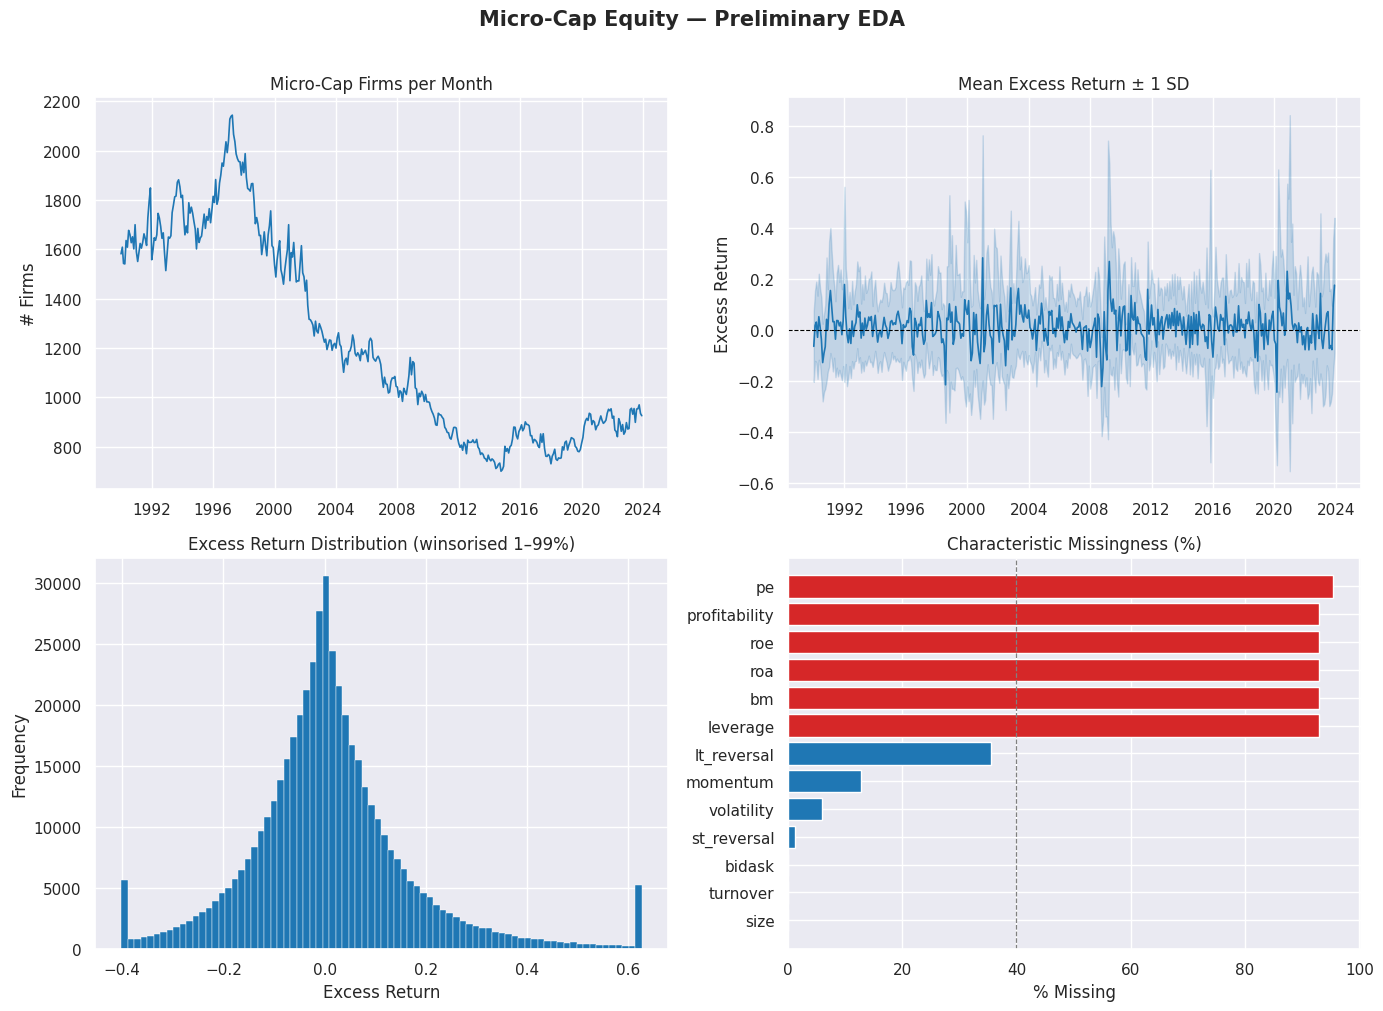

In [ ]:
sns.set_theme(style="darkgrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Micro-Cap Equity — Preliminary EDA", fontsize=15, fontweight="bold", y=1.01)

mc = df[df["is_microcap"]]

# 1. firms per month
firms_pm = mc.groupby("month")["permno"].nunique()
axes[0,0].plot(firms_pm.index, firms_pm.values, color="#1f77b4", lw=1.2)
axes[0,0].set_title("Micro-Cap Firms per Month")
axes[0,0].set_ylabel("# Firms")

# 2. mean excess return over time
monthly_ret = mc.groupby("month")["excess_ret"].agg(["mean","std"])
axes[0,1].fill_between(monthly_ret.index,
                        monthly_ret["mean"] - monthly_ret["std"],
                        monthly_ret["mean"] + monthly_ret["std"],
                        alpha=0.2, color="#1f77b4")
axes[0,1].plot(monthly_ret.index, monthly_ret["mean"], color="#1f77b4", lw=1.2)
axes[0,1].axhline(0, color="black", lw=0.8, ls="--")
axes[0,1].set_title("Mean Excess Return ± 1 SD")
axes[0,1].set_ylabel("Excess Return")

# 3. excess return distribution
mc["excess_ret"].clip(mc["excess_ret"].quantile(0.01),
                      mc["excess_ret"].quantile(0.99)).plot.hist(
    ax=axes[1,0], bins=80, color="#1f77b4", edgecolor="white", lw=0.3
)
axes[1,0].set_title("Excess Return Distribution (winsorised 1–99%)")
axes[1,0].set_xlabel("Excess Return")
axes[1,0].set_ylabel("Frequency")

# 4. characteristic missingness
chars = ["size","turnover","bidask","volatility","bm","pe",
         "roa","roe","profitability","leverage","momentum","st_reversal","lt_reversal"]
miss = mc[chars].isnull().mean().mul(100).sort_values(ascending=True)
colors = ["#d62728" if v > 40 else "#1f77b4" for v in miss.values]
axes[1,1].barh(miss.index, miss.values, color=colors, edgecolor="white")
axes[1,1].axvline(40, color="grey", ls="--", lw=0.9)
axes[1,1].set_title("Characteristic Missingness (%)")
axes[1,1].set_xlabel("% Missing")

plt.tight_layout()
plt.show()